In [1]:
import pandas as pd
%matplotlib inline
%config Completer.use_jedi = False

pd.set_option("display.max_rows",500)
pd.set_option('max_colwidth', 400)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split

In [21]:
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin']

dataset = pd.read_csv("auto-mpg.data", names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)

In [22]:
dataset.head()
foo=dataset.Horsepower.isna()
foo.shape

(398,)

In [23]:
dataset.isna().sum()
#dataset=dataset.dropna(axis=0)
#dataset['Horsepower']=dataset.Horsepower.fillna(dataset.Horsepower.mean())
#par Cylinders
dataset['Horsepower']=dataset.groupby('Cylinders')['Horsepower'].transform(lambda x: x.fillna(x.mean()))
#vérif des correctsion sur foo
dataset[foo]

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
32,25.0,4,98.0,78.281407,2046.0,19.0,71,1
126,21.0,6,200.0,101.506024,2875.0,17.0,74,1
330,40.9,4,85.0,78.281407,1835.0,17.3,80,2
336,23.6,4,140.0,78.281407,2905.0,14.3,80,1
354,34.5,4,100.0,78.281407,2320.0,15.8,81,2
374,23.0,4,151.0,78.281407,3035.0,20.5,82,1


In [ ]:
dataset["Origin"]=dataset.Origin.replace({1:'USA', 2:'Europe', 3:'Japan'})
dataset[foo]
dataset=pd.get_dummies(dataset, columns=['Origin'])
dataset.head()


C:\Users\lione\AppData\Local\Temp\ipykernel_31140\3414877349.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataset["Origin"]=dataset.Origin.replace({1:'USA', 2:'Europe', 3:'Japan'}, inplace=True)


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin_Europe,Origin_Japan,Origin_USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433.0,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449.0,10.5,70,False,False,True



plus on a de puissance et de poids plus on est négativement corrélé à la conso MPG
au USA principalement



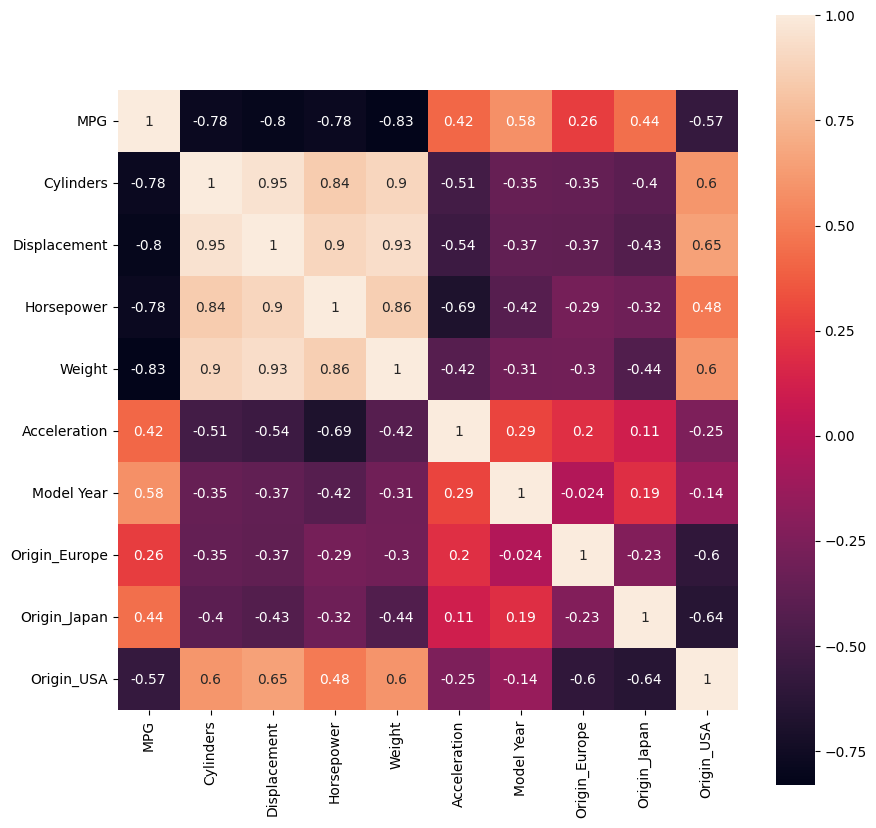

In [27]:
plt.subplots(figsize=(10,10))
sns.heatmap(dataset.corr(),annot=True,square=True)
print("""
plus on a de puissance et de poids plus on est négativement corrélé à la conso MPG
au USA principalement
""")

In [34]:
display(dataset.describe(),print("""
    Nous avons un mixte de variables continue de différents ordre de grandeur et trois variables catégoriels
    ainsi une normalisation est necessaire sur les X_train et X_test
    """)
)


    Nous avons un mixte de variables continue de différents ordre de grandeur et trois variables catégoriels
    ainsi une normalisation est necessaire sur les X_train et X_test
    


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.132947,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.310886,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,92.000000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


None

In [35]:
y=dataset.MPG
X=dataset.drop(columns=["MPG"])

In [36]:
from sklearn.preprocessing import MinMaxScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler=MinMaxScaler()
X_train_scalled = scaler.fit_transform (X_train)
X_test_scalled = scaler.fit_transform(X_test)
X_train_scalled.shape

(318, 9)

Premier Modèle

In [38]:
from tensorflow.keras.models import Sequential
linear_model = Sequential()
linear_model.add(Input(shape=(9,)))
linear_model.add(Dense(units=1,activation="linear",kernel_initializer="normal"))

In [39]:
linear_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
from tensorflow.keras.optimizers import Adam
linear_model.compile(optimizer=Adam(learning_rate=0.1), loss="mean_absolute_error" ) #, metrics=["mae"])

In [42]:
linear_history=linear_model.fit(X_train_scalled,y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 22.1001 - val_loss: 20.3584
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18.5598 - val_loss: 16.9199
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15.0478 - val_loss: 13.6109
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12.2732 - val_loss: 11.5147
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.6845 - val_loss: 10.3241
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.7791 - val_loss: 9.4768
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.0281 - val_loss: 8.7558
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.3861 - val_loss: 8.0775
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.7443 - val_loss: 7.3868
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.1099 - val_loss: 6.7908
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.4837 - val_loss: 6.2285
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.9243 - val_los

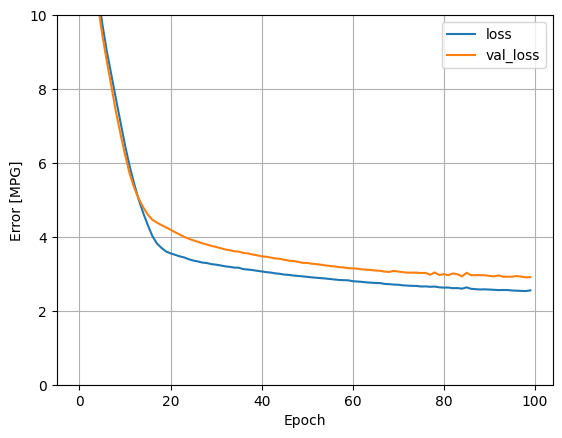

In [43]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.ylim([0,10])
    plt.xlabel('Epoch')
    plt.ylabel('Error [MPG]')
    plt.legend()
    plt.grid(True)

plot_loss(linear_history)

In [56]:
test_results = {}

test_results['linear_model'] = linear_model.evaluate(X_test_scalled, y_test, verbose = 0)

In [45]:
dnn_model = Sequential()
dnn_model.add(Input(shape=(9,)))
dnn_model.add(Dense(units=64, activation="relu", kernel_initializer="normal"))
dnn_model.add(Dense(units=64, activation="relu", kernel_initializer="normal"))
dnn_model.add(Dense(units=1, activation="linear", kernel_initializer="normal"))

In [46]:
dnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
dnn_model.compile(optimizer=Adam(learning_rate=0.001), loss="mean_absolute_error" ) #, metrics=["mae"])
dnn_history=dnn_model.fit(X_train_scalled,y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 23.5572 - val_loss: 23.6567
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 23.4837 - val_loss: 23.5591
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 23.3478 - val_loss: 23.3673
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 23.0813 - val_loss: 23.0062
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.5917 - val_loss: 22.3693
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 21.7586 - val_loss: 21.3149
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20.4186 - val_loss: 19.6806
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18.3920 - val_loss: 17.2736
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15.4954 - val_loss: 13.9320
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12.2719 - val_loss: 11.1579
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10.2402 - val_loss: 9.8172
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.510

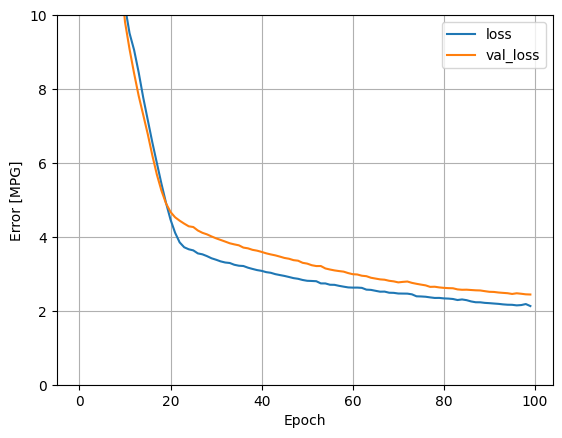

In [48]:
plot_loss(dnn_history)

In [58]:
test_results['dnn_model'] = dnn_model.evaluate(X_test_scalled, y_test, verbose=0)

Performance

In [60]:
pd.DataFrame(test_results, index=['Mean absolute error [MPG]']).T

,Mean absolute error [MPG]
linear_model,2.247011
dnn_model,1.970135


In [ ]:
print("réduction de 0.27 MAE de MPG avec le DNN par rapport au linear model - on converge plus en DNN")

Prédiction

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


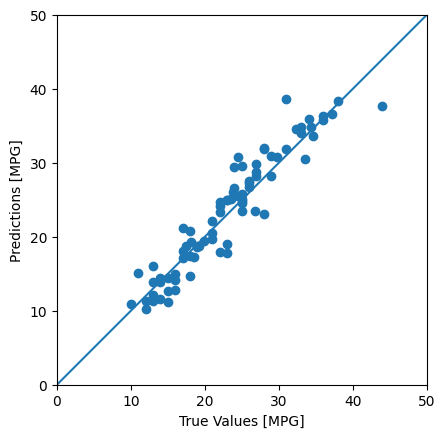

In [61]:
test_predictions = dnn_model.predict(X_test_scalled).flatten()

a = plt.axes(aspect='equal')
plt.scatter(y_test, test_predictions)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
lims = [0, 50]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

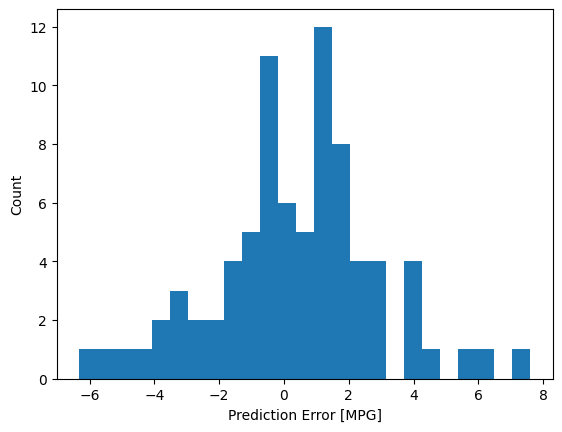

: 

In [ ]:
error = test_predictions - y_test
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [MPG]')
_ = plt.ylabel('Count')